# Analyze DQN training runs

Interactive companion to `analyze_runs.py` — same discovery/metrics logic (imported, not duplicated), but renders the leaderboard table and plots inline instead of writing files, so you can poke at parameters without re-running a script.

Re-run a cell after changing `ROOT`/`METRIC`/`WINDOW` below to refresh everything downstream.

In [23]:
%matplotlib inline
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "analyze_runs.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from analyze_runs import (
    build_summary,
    find_completed_runs,
    known_non_variable_columns,
    smoothed,
)

pd.set_option("display.max_colwidth", 60)
pd.set_option("display.width", 200)

In [24]:
# Parameters — tweak these and re-run the cells below
ROOT = PROJECT_ROOT / "outputs" / "dqn_runs"
METRIC = "success_rate_last"  # one of: mean_reward_all, mean_reward_last, best_reward, success_rate_all, success_rate_last
WINDOW = 100  # episode window for moving averages / "_last" metrics
TOP_N = 10

In [25]:
run_dirs = find_completed_runs(ROOT)
print(f"Found {len(run_dirs)} completed run(s) under {ROOT}")

df = build_summary(run_dirs, WINDOW)
df.sort_values(METRIC, ascending=False).head(TOP_N)

Found 138 completed run(s) under c:\Users\LoveTriangle\Documents\LoveTriangle_robots\outputs\dqn_runs


,run_dir,condition,seed,n_actions,training.lr,training.gamma,n_episodes,mean_reward_all,mean_reward_last,best_reward,...,success_rate_all,success_rate_last,reward.green_hit_threshold,reward.green_hit_bonus,reward.green_shaping_coef,reward.red_hit_threshold,reward.red_hit_penalty,reward.red_shaping_coef,reward.wall_threshold,reward.wall_penalty_coef
2,c:\Users\LoveTriangle\Documents\LoveTriangle_robots\outp...,multi-blocking-orbit-separated,7,9,0.0010,0.95,10000,-26.453802,-1.548305,477.924195,...,0.6343,0.74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,c:\Users\LoveTriangle\Documents\LoveTriangle_robots\outp...,multi-blocking-orbit-separated,7,9,0.0010,0.99,10000,-13.822164,15.394054,1202.905243,...,0.6394,0.72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,c:\Users\LoveTriangle\Documents\LoveTriangle_robots\outp...,multi-random,7,9,0.0010,NaN,10000,-105.696773,-76.350494,102.479379,...,0.5178,0.66,10.0,100.0,0.1,10.0,100.0,0.05,40.0,5.0
0,c:\Users\LoveTriangle\Documents\LoveTriangle_robots\outp...,multi-blocking-orbit-separated,7,9,0.0003,0.95,10000,-30.252074,-10.524678,356.035793,...,0.6179,0.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
115,c:\Users\LoveTriangle\Documents\LoveTriangle_robots\outp...,multi-random,7,9,0.0010,NaN,10000,-318.569812,-232.905880,102.360415,...,0.5818,0.64,10.0,100.0,0.2,20.0,100.0,0.05,20.0,10.0
117,c:\Users\LoveTriangle\Documents\LoveTriangle_robots\outp...,multi-random,7,9,0.0010,NaN,10000,-321.902469,-245.957949,102.445573,...,0.5782,0.63,10.0,100.0,0.2,20.0,100.0,0.05,40.0,10.0
114,c:\Users\LoveTriangle\Documents\LoveTriangle_robots\outp...,multi-random,7,9,0.0010,NaN,10000,-320.226082,-233.786736,102.430406,...,0.5521,0.63,10.0,100.0,0.2,20.0,100.0,0.05,20.0,5.0
99,c:\Users\LoveTriangle\Documents\LoveTriangle_robots\outp...,multi-random,7,9,0.0010,NaN,10000,-305.383639,-206.823258,102.253603,...,0.5710,0.63,10.0,100.0,0.2,10.0,150.0,0.05,40.0,10.0
1,c:\Users\LoveTriangle\Documents\LoveTriangle_robots\outp...,multi-blocking-orbit-separated,7,9,0.0003,0.99,10000,-20.312600,-3.057310,1146.318077,...,0.5886,0.62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
81,c:\Users\LoveTriangle\Documents\LoveTriangle_robots\outp...,multi-random,7,9,0.0010,NaN,10000,-301.049760,-200.019993,102.365326,...,0.5691,0.62,10.0,100.0,0.2,10.0,100.0,0.05,40.0,10.0


## Best run vs. all others

Reward curve (moving average over `WINDOW` episodes) for every completed run in light grey, with the run ranked highest by `METRIC` highlighted in red.

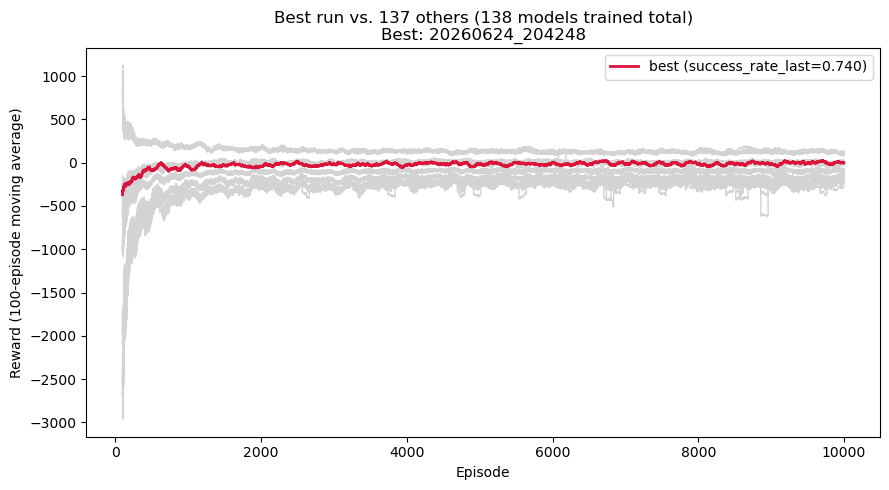

Best run directory: c:\Users\LoveTriangle\Documents\LoveTriangle_robots\outputs\dqn_runs\config_cond-multi-blocking-orbit-separated_seed-7_training.lr=0.001_training.gamma=0.95\multi-blocking-orbit-separated\20260624_204248
Policy: c:\Users\LoveTriangle\Documents\LoveTriangle_robots\outputs\dqn_runs\config_cond-multi-blocking-orbit-separated_seed-7_training.lr=0.001_training.gamma=0.95\multi-blocking-orbit-separated\20260624_204248\policies\final_policy.pt
Training-time rollout figures: c:\Users\LoveTriangle\Documents\LoveTriangle_robots\outputs\dqn_runs\config_cond-multi-blocking-orbit-separated_seed-7_training.lr=0.001_training.gamma=0.95\multi-blocking-orbit-separated\20260624_204248\figures


run_dir                       c:\Users\LoveTriangle\Documents\LoveTriangle_robots\outp...
condition                                                  multi-blocking-orbit-separated
seed                                                                                    7
n_actions                                                                               9
training.lr                                                                         0.001
training.gamma                                                                       0.95
n_episodes                                                                          10000
mean_reward_all                                                                -26.453802
mean_reward_last                                                                -1.548305
best_reward                                                                    477.924195
mean_duration_last                                                                  29.15
success_ra

In [26]:
best_idx = df[METRIC].idxmax()
best_row = df.loc[best_idx]

fig, ax = plt.subplots(figsize=(9, 5))
for idx, row in df.iterrows():
    rewards = pd.read_csv(Path(row["run_dir"]) / "training_metrics.csv")["reward"].to_numpy()
    x, y = smoothed(rewards, WINDOW)
    if idx == best_idx:
        continue
    ax.plot(x, y, color="lightgray", linewidth=1, zorder=1)

best_rewards = pd.read_csv(Path(best_row["run_dir"]) / "training_metrics.csv")["reward"].to_numpy()
x, y = smoothed(best_rewards, WINDOW)
ax.plot(x, y, color="crimson", linewidth=2, zorder=2, label=f"best ({METRIC}={best_row[METRIC]:.3f})")

ax.set_xlabel("Episode")
ax.set_ylabel(f"Reward ({WINDOW}-episode moving average)")
ax.set_title(f"Best run vs. {len(df) - 1} others ({len(df)} models trained total)\nBest: {Path(best_row['run_dir']).name}")
ax.legend()
fig.tight_layout()
plt.show()

print("Best run directory:", best_row["run_dir"])
print("Policy:", Path(best_row["run_dir"]) / "policies" / "final_policy.pt")
print("Training-time rollout figures:", Path(best_row["run_dir"]) / "figures")
best_row

## Variables we varied

Every hyperparameter that took on 2+ distinct values across the trained models, and what those values were.

In [ ]:
variable_cols = [c for c in df.columns if c not in known_non_variable_columns()]
swept_cols = [c for c in variable_cols if df[c].nunique(dropna=True) >= 2]

swept_vars = pd.DataFrame(
    {
        "variable": swept_cols,
        "values": [sorted(df[c].dropna().unique().tolist(), key=str) for c in swept_cols],
        "n_distinct_values": [df[c].nunique(dropna=True) for c in swept_cols],
    }
)

print(f"{len(df)} models trained, varying {len(swept_cols)} hyperparameter(s):")
swept_vars

## Metric vs. each swept variable

One scatter per hyperparameter that actually varies across the discovered runs (parsed from each run's `run_config.json` → `cli_args.overrides`), showing how it relates to `METRIC`.

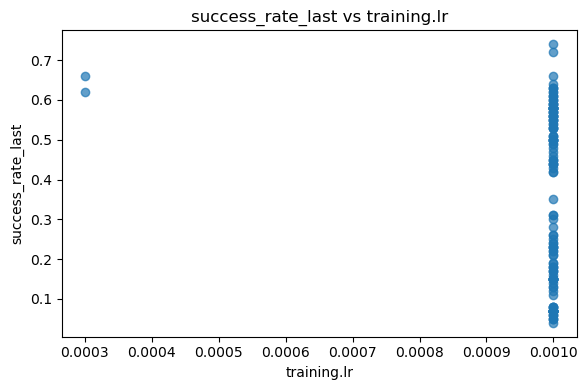

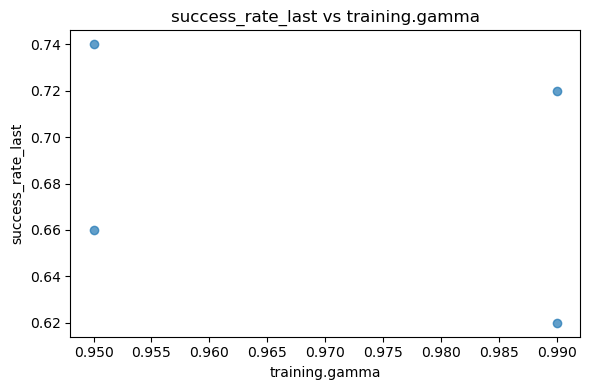

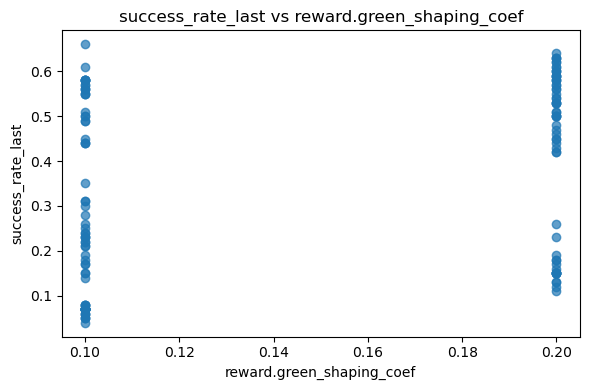

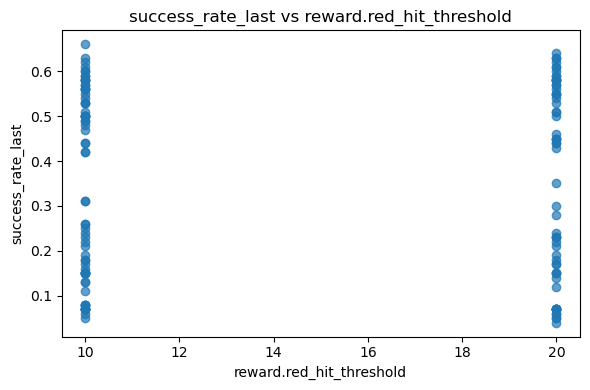

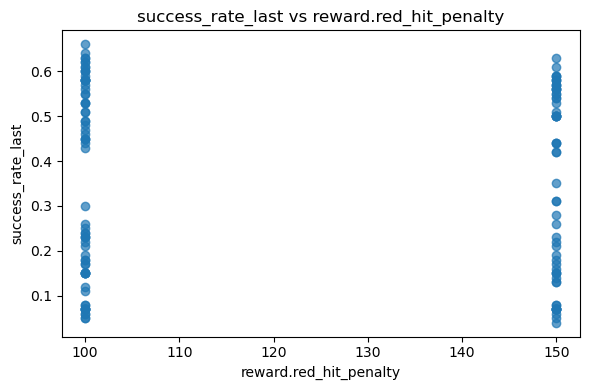

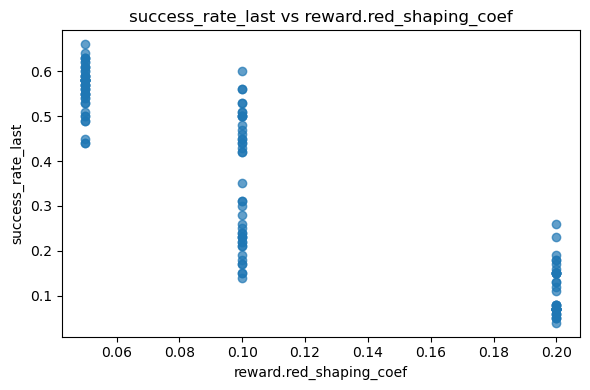

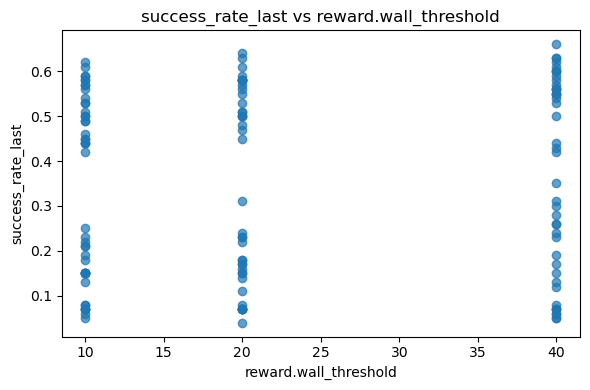

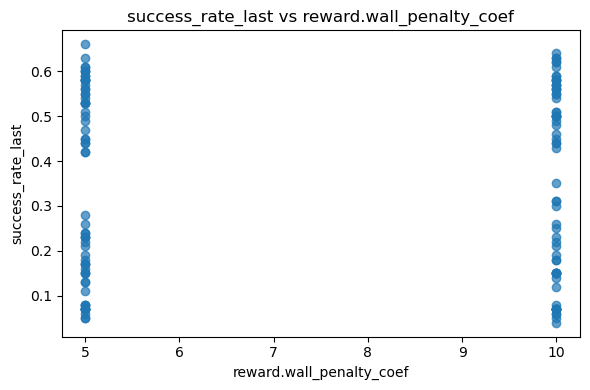

In [27]:
variable_cols = [c for c in df.columns if c not in known_non_variable_columns()]
plotted_any = False

for col in variable_cols:
    sub = df[[col, METRIC]].dropna()
    if sub[col].nunique() < 2:
        continue
    plotted_any = True

    fig, ax = plt.subplots(figsize=(6, 4))
    if pd.api.types.is_numeric_dtype(sub[col]):
        ax.scatter(sub[col], sub[METRIC], alpha=0.7)
        ax.set_xlabel(col)
    else:
        categories = sorted(sub[col].astype(str).unique())
        positions = {c: i for i, c in enumerate(categories)}
        xs = sub[col].astype(str).map(positions)
        ax.scatter(xs, sub[METRIC], alpha=0.7)
        ax.set_xticks(range(len(categories)))
        ax.set_xticklabels(categories, rotation=30, ha="right")
        ax.set_xlabel(col)

    ax.set_ylabel(METRIC)
    ax.set_title(f"{METRIC} vs {col}")
    fig.tight_layout()
    plt.show()
    plt.close(fig)

if not plotted_any:
    print("No swept variable had 2+ distinct values across the discovered runs.")

## Full leaderboard

Every completed run, every parsed override column, every metric — sort/filter as needed (e.g. `df[df["reward.wall_penalty_coef"] == 10.0]`).

In [28]:
df

,run_dir,condition,seed,n_actions,training.lr,training.gamma,n_episodes,mean_reward_all,mean_reward_last,best_reward,...,success_rate_all,success_rate_last,reward.green_hit_threshold,reward.green_hit_bonus,reward.green_shaping_coef,reward.red_hit_threshold,reward.red_hit_penalty,reward.red_shaping_coef,reward.wall_threshold,reward.wall_penalty_coef
0,c:\Users\LoveTriangle\Documents\LoveTriangle_robots\outp...,multi-blocking-orbit-separated,7,9,0.0003,0.95,10000,-30.252074,-10.524678,356.035793,...,0.6179,0.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,c:\Users\LoveTriangle\Documents\LoveTriangle_robots\outp...,multi-blocking-orbit-separated,7,9,0.0003,0.99,10000,-20.312600,-3.057310,1146.318077,...,0.5886,0.62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,c:\Users\LoveTriangle\Documents\LoveTriangle_robots\outp...,multi-blocking-orbit-separated,7,9,0.0010,0.95,10000,-26.453802,-1.548305,477.924195,...,0.6343,0.74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,c:\Users\LoveTriangle\Documents\LoveTriangle_robots\outp...,multi-blocking-orbit-separated,7,9,0.0010,0.99,10000,-13.822164,15.394054,1202.905243,...,0.6394,0.72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,c:\Users\LoveTriangle\Documents\LoveTriangle_robots\outp...,multi-random,7,9,0.0010,NaN,10000,-104.156711,-75.127482,102.502467,...,0.4842,0.49,10.0,100.0,0.1,10.0,100.0,0.05,10.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,c:\Users\LoveTriangle\Documents\LoveTriangle_robots\outp...,multi-random,7,9,0.0010,NaN,10000,-329.206808,-241.776974,102.246761,...,0.5627,0.57,10.0,100.0,0.2,20.0,150.0,0.05,20.0,10.0
134,c:\Users\LoveTriangle\Documents\LoveTriangle_robots\outp...,multi-random,7,9,0.0010,NaN,10000,-328.508746,-246.474651,102.444010,...,0.5687,0.59,10.0,100.0,0.2,20.0,150.0,0.05,40.0,5.0
135,c:\Users\LoveTriangle\Documents\LoveTriangle_robots\outp...,multi-random,7,9,0.0010,NaN,10000,-336.597147,-243.930166,102.426378,...,0.5567,0.55,10.0,100.0,0.2,20.0,150.0,0.05,40.0,10.0
136,c:\Users\LoveTriangle\Documents\LoveTriangle_robots\outp...,multi-random,7,9,0.0010,NaN,10000,-239.822471,-169.140336,104.964381,...,0.4617,0.44,10.0,100.0,0.2,20.0,150.0,0.10,10.0,5.0


## How many models per hyperparameter value

Bar chart of run counts for each swept hyperparameter (how many runs used each distinct value), plus the count of runs per unique hyperparameter *combination*.

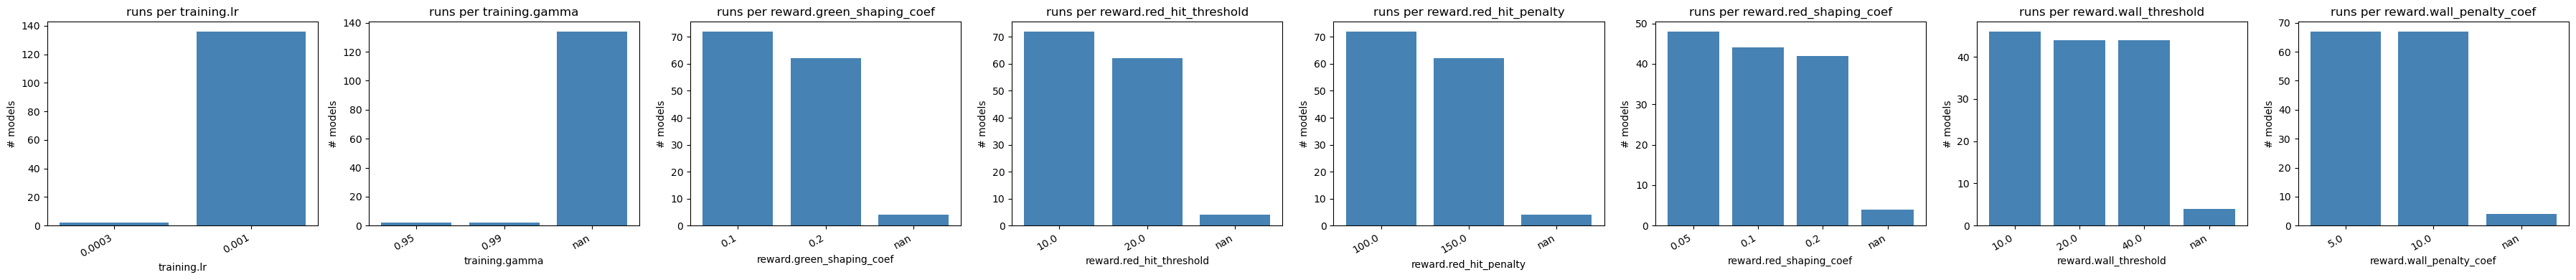

138 unique hyperparameter combination(s) across 138 models


,training.lr,training.gamma,reward.green_shaping_coef,reward.red_hit_threshold,reward.red_hit_penalty,reward.red_shaping_coef,reward.wall_threshold,reward.wall_penalty_coef,n_models
0,0.0003,0.95,NaN,NaN,NaN,NaN,NaN,NaN,1
1,0.0003,0.99,NaN,NaN,NaN,NaN,NaN,NaN,1
2,0.0010,0.95,NaN,NaN,NaN,NaN,NaN,NaN,1
3,0.0010,0.99,NaN,NaN,NaN,NaN,NaN,NaN,1
4,0.0010,NaN,0.1,10.0,100.0,0.05,10.0,5.0,1
...,...,...,...,...,...,...,...,...,...
133,0.0010,NaN,0.2,20.0,150.0,0.05,20.0,10.0,1
134,0.0010,NaN,0.2,20.0,150.0,0.05,40.0,5.0,1
135,0.0010,NaN,0.2,20.0,150.0,0.05,40.0,10.0,1
136,0.0010,NaN,0.2,20.0,150.0,0.10,10.0,5.0,1


In [29]:
swept_cols = [c for c in variable_cols if df[c].nunique(dropna=True) >= 2]

n = len(swept_cols)
fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4), squeeze=False)
for ax, col in zip(axes[0], swept_cols):
    counts = df[col].value_counts(dropna=False).sort_index()
    labels = [str(v) for v in counts.index]
    ax.bar(labels, counts.values, color="steelblue")
    ax.set_title(f"runs per {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("# models")
    ax.tick_params(axis="x", rotation=30)
    for tick in ax.get_xticklabels():
        tick.set_ha("right")
fig.tight_layout()
plt.show()

combo_counts = df.groupby(swept_cols, dropna=False).size().rename("n_models").reset_index()
combo_counts = combo_counts.sort_values("n_models", ascending=False)
print(f"{len(combo_counts)} unique hyperparameter combination(s) across {len(df)} models")
combo_counts

## Metric by condition

Distribution of `METRIC` for each `condition` (e.g. `multi-blocking-orbit-separated` vs `multi-random`), with the number of runs per condition.

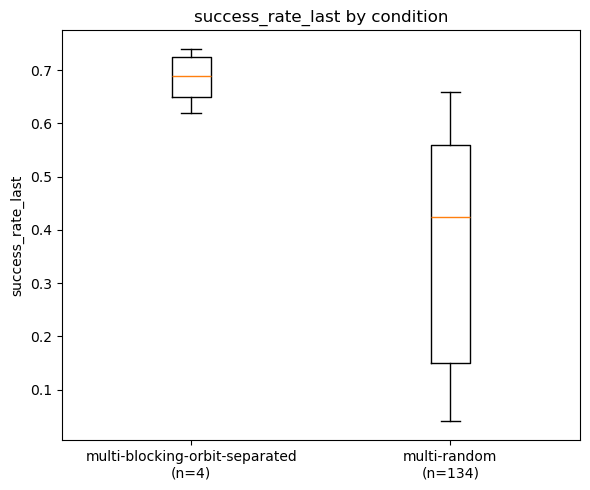

In [30]:
conditions = sorted(df["condition"].dropna().unique())
data = [df.loc[df["condition"] == c, METRIC].dropna().to_numpy() for c in conditions]
counts = [len(d) for d in data]

fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot(data, tick_labels=[f"{c}\n(n={n})" for c, n in zip(conditions, counts)])
ax.set_ylabel(METRIC)
ax.set_title(f"{METRIC} by condition")
fig.tight_layout()
plt.show()